<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/NARX_Multiobjetivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NARX + NSGA-II MULTIOBJETIVO
# Dados originais em segundos → média de 60 s → dados em minutos
# Previsão de 2 minutos à frente = 120 segundos
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from google.colab import files
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# ============================================================
# 1. Upload
# ============================================================

print("Faça upload do arquivo Excel (.xlsx)")
uploaded = files.upload()

arquivo = list(uploaded.keys())[0]
df_sec = pd.read_excel(arquivo).dropna().reset_index(drop=True)

print("Dataset original em segundos:", df_sec.shape)
print("Colunas:", list(df_sec.columns))


Faça upload do arquivo Excel (.xlsx)


Saving Wobb_Virtual.xlsx to Wobb_Virtual.xlsx
Dataset original em segundos: (172800, 5)
Colunas: ['y', 'u1', 'u2', 'u3', 'u4']


In [3]:
# ============================================================
# 2. Conversão segundos → minutos
# ============================================================

JANELA_SEGUNDOS = 60

df_min = (
    df_sec
    .groupby(df_sec.index // JANELA_SEGUNDOS)
    .mean(numeric_only=True)
    .reset_index(drop=True)
)

print("Dataset convertido para minutos:", df_min.shape)

Dataset convertido para minutos: (2880, 5)


In [10]:
# ============================================================
# 3. Configuração do problema
# ============================================================

col_y = df_min.columns[0]
cols_u = list(df_min.columns[1:])

# 2 passos em minutos = 2 minutos = 120 segundos
H = 1

max_lag_y = 5
max_lag_u = 5
graus = [1, 2]

pop_size = 25
generations = 20
mutation_rate = 0.06
prob_termo_inicial = 0.12

random.seed(10)
np.random.seed(10)

In [11]:
# ============================================================
# 4. Funções auxiliares
# ============================================================

cache = {}

def build_dataset(lag_y, lag_u, grau):
    key = (lag_y, lag_u, grau)

    if key in cache:
        return cache[key]

    data = pd.DataFrame(index=df_min.index)

    data[f"{col_y}_t"] = df_min[col_y]

    for lag in range(1, lag_y + 1):
        data[f"{col_y}_t-{lag}"] = df_min[col_y].shift(lag)

    for col in cols_u:
        data[f"{col}_t"] = df_min[col]

        for lag in range(1, lag_u + 1):
            data[f"{col}_t-{lag}"] = df_min[col].shift(lag)

    target_col = f"{col_y}_target_t+{H}"
    data[target_col] = df_min[col_y].shift(-H)

    data = data.dropna().reset_index(drop=True)

    X_base = data.drop(columns=[target_col])
    y = data[target_col].values

    split = int(0.8 * len(X_base))

    X_train_base = X_base.iloc[:split]
    X_test_base = X_base.iloc[split:]

    y_train = y[:split]
    y_test = y[split:]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_base)
    X_test_scaled = scaler.transform(X_test_base)

    poly = PolynomialFeatures(degree=grau, include_bias=False)

    X_train = poly.fit_transform(X_train_scaled)
    X_test = poly.transform(X_test_scaled)

    names = poly.get_feature_names_out(X_base.columns)

    out = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "names": names,
        "scaler": scaler,
        "poly": poly,
        "feature_cols": X_base.columns
    }

    cache[key] = out
    return out


def compute_cost(mask, names):
    """
    Estimativa simples de custo PLC.

    Termo linear:
        coef * x + soma → custo 2

    Termo quadrático/produto:
        x1*x2 ou x^2 + coef*soma → custo 4
    """

    cost = 0

    for i, active in enumerate(mask):
        if not active:
            continue

        term = str(names[i])

        if (" " in term) or ("^" in term):
            cost += 4
        else:
            cost += 2

    return cost


def ajustar_mask(mask, n_features):
    if mask is None:
        nova = np.random.rand(n_features) < prob_termo_inicial
    else:
        nova = np.zeros(n_features, dtype=bool)
        n_copy = min(len(mask), n_features)
        nova[:n_copy] = mask[:n_copy]

    if np.sum(nova) == 0:
        nova[random.randint(0, n_features - 1)] = True

    return nova


class Individual:
    def __init__(self):
        self.lag_y = random.randint(1, max_lag_y)
        self.lag_u = random.randint(1, max_lag_u)
        self.grau = random.choice(graus)
        self.mask = None
        self.rank = 0
        self.crowding = 0

    def evaluate(self):
        ds = build_dataset(self.lag_y, self.lag_u, self.grau)

        Xtr_all = ds["X_train"]
        Xte_all = ds["X_test"]
        ytr = ds["y_train"]
        yte = ds["y_test"]
        names = ds["names"]

        self.mask = ajustar_mask(self.mask, Xtr_all.shape[1])

        Xtr = Xtr_all[:, self.mask]
        Xte = Xte_all[:, self.mask]

        model = LinearRegression()
        model.fit(Xtr, ytr)

        yhat = model.predict(Xte)
        erro = yte - yhat

        self.rmse = float(np.sqrt(mean_squared_error(yte, yhat)))
        self.mae = float(mean_absolute_error(yte, yhat))
        self.r2 = float(r2_score(yte, yhat))
        self.robust = float(np.std(erro))
        self.cost = int(compute_cost(self.mask, names))
        self.n_terms = int(np.sum(self.mask))

        self.model = model
        self.y_test = yte
        self.y_pred_test = yhat
        self.names = names


def dominates(a, b):
    return (
        a.rmse <= b.rmse and
        a.cost <= b.cost and
        a.robust <= b.robust
    ) and (
        a.rmse < b.rmse or
        a.cost < b.cost or
        a.robust < b.robust
    )


def fast_sort(pop):
    fronts = [[]]

    for p in pop:
        p.dom_count = 0
        p.dom_set = []

        for q in pop:
            if p is q:
                continue

            if dominates(p, q):
                p.dom_set.append(q)

            elif dominates(q, p):
                p.dom_count += 1

        if p.dom_count == 0:
            p.rank = 0
            fronts[0].append(p)

    i = 0

    while i < len(fronts) and len(fronts[i]) > 0:
        nxt = []

        for p in fronts[i]:
            for q in p.dom_set:
                q.dom_count -= 1

                if q.dom_count == 0:
                    q.rank = i + 1
                    nxt.append(q)

        i += 1
        fronts.append(nxt)

    return fronts


def crowding(front):
    if len(front) == 0:
        return

    if len(front) <= 2:
        for p in front:
            p.crowding = float("inf")
        return

    for p in front:
        p.crowding = 0

    for obj in ["rmse", "cost", "robust"]:
        front.sort(key=lambda x: getattr(x, obj))

        front[0].crowding = float("inf")
        front[-1].crowding = float("inf")

        mn = getattr(front[0], obj)
        mx = getattr(front[-1], obj)

        if mx - mn == 0:
            continue

        for i in range(1, len(front) - 1):
            front[i].crowding += (
                getattr(front[i + 1], obj) -
                getattr(front[i - 1], obj)
            ) / (mx - mn)


def tournament(pop):
    a, b = random.sample(pop, 2)

    if a.rank < b.rank:
        return a

    if b.rank < a.rank:
        return b

    return a if a.crowding > b.crowding else b


def clone(parent):
    child = Individual()
    child.lag_y = parent.lag_y
    child.lag_u = parent.lag_u
    child.grau = parent.grau
    child.mask = parent.mask.copy()
    return child


def mutate(child):
    if random.random() < mutation_rate:
        child.lag_y = random.randint(1, max_lag_y)

    if random.random() < mutation_rate:
        child.lag_u = random.randint(1, max_lag_u)

    if random.random() < mutation_rate:
        child.grau = random.choice(graus)

    if child.mask is not None:
        for i in range(len(child.mask)):
            if random.random() < mutation_rate:
                child.mask[i] = not child.mask[i]

    return child

In [12]:
# ============================================================
# 5. Execução NSGA-II
# ============================================================

pop = [Individual() for _ in range(pop_size)]

for ind in pop:
    ind.evaluate()

for gen in range(generations):
    fronts = fast_sort(pop)

    for f in fronts:
        if f:
            crowding(f)

    offspring = []

    while len(offspring) < pop_size:
        parent = tournament(pop)
        child = mutate(clone(parent))
        child.evaluate()
        offspring.append(child)

    combined = pop + offspring
    fronts = fast_sort(combined)

    new_pop = []

    for f in fronts:
        if not f:
            continue

        crowding(f)

        if len(new_pop) + len(f) <= pop_size:
            new_pop.extend(f)

        else:
            new_pop.extend(
                sorted(f, key=lambda x: x.crowding, reverse=True)
                [:pop_size - len(new_pop)]
            )
            break

    pop = new_pop

    pareto_gen = fast_sort(pop)[0]

    print(
        f"Geração {gen+1}/{generations} | "
        f"RMSE min={min(p.rmse for p in pareto_gen):.4f} | "
        f"Custo min={min(p.cost for p in pareto_gen)} | "
        f"Robustez min={min(p.robust for p in pareto_gen):.4f}"
    )


Geração 1/20 | RMSE min=0.0473 | Custo min=2 | Robustez min=0.0473
Geração 2/20 | RMSE min=0.0453 | Custo min=2 | Robustez min=0.0450
Geração 3/20 | RMSE min=0.0450 | Custo min=2 | Robustez min=0.0448
Geração 4/20 | RMSE min=0.0450 | Custo min=2 | Robustez min=0.0448
Geração 5/20 | RMSE min=0.0450 | Custo min=2 | Robustez min=0.0448
Geração 6/20 | RMSE min=0.0450 | Custo min=2 | Robustez min=0.0448
Geração 7/20 | RMSE min=0.0441 | Custo min=2 | Robustez min=0.0439
Geração 8/20 | RMSE min=0.0439 | Custo min=2 | Robustez min=0.0437
Geração 9/20 | RMSE min=0.0439 | Custo min=2 | Robustez min=0.0437
Geração 10/20 | RMSE min=0.0439 | Custo min=2 | Robustez min=0.0437
Geração 11/20 | RMSE min=0.0437 | Custo min=2 | Robustez min=0.0434
Geração 12/20 | RMSE min=0.0437 | Custo min=2 | Robustez min=0.0434
Geração 13/20 | RMSE min=0.0437 | Custo min=2 | Robustez min=0.0434
Geração 14/20 | RMSE min=0.0437 | Custo min=2 | Robustez min=0.0434
Geração 15/20 | RMSE min=0.0435 | Custo min=2 | Robustez 

In [13]:
# ============================================================
# 6. Pareto final
# ============================================================

pareto = fast_sort(pop)[0]

unique = {}

for p in pareto:
    key = (
        round(p.rmse, 6),
        p.cost,
        round(p.robust, 6),
        p.lag_y,
        p.lag_u,
        p.grau,
        p.n_terms
    )
    unique[key] = p

pareto = list(unique.values())

df_pareto = pd.DataFrame([{
    "RMSE": p.rmse,
    "MAE": p.mae,
    "R2": p.r2,
    "Custo_PLC": p.cost,
    "Robustez_std_erro": p.robust,
    "N_Termos": p.n_terms,
    "Lag_Y": p.lag_y,
    "Lag_U": p.lag_u,
    "Grau": p.grau
} for p in pareto]).sort_values(["RMSE", "Custo_PLC"]).reset_index(drop=True)

print("\nFronteira de Pareto:")
display(df_pareto)


Fronteira de Pareto:


,RMSE,MAE,R2,Custo_PLC,Robustez_std_erro,N_Termos,Lag_Y,Lag_U,Grau
0,0.043545,0.019115,0.861297,22,0.043318,11,4,4,1
1,0.043764,0.018209,0.859900,20,0.043538,10,4,4,1
2,0.043790,0.018208,0.859729,18,0.043569,9,4,4,1
3,0.044402,0.018186,0.855785,16,0.044308,8,5,1,1
4,0.044442,0.018179,0.855524,14,0.044346,7,5,1,1
5,0.044454,0.019277,0.855446,16,0.044279,8,4,4,1
6,0.044640,0.018233,0.854237,12,0.044533,6,5,1,1
7,0.045528,0.018437,0.848375,10,0.045274,5,5,1,1
8,0.045565,0.018620,0.848130,10,0.045239,5,4,1,1
9,0.045807,0.018061,0.847381,6,0.045771,3,2,1,1


In [14]:
# ============================================================
# 7. Escolha do modelo de compromisso
# ============================================================

rmse_vals = np.array([p.rmse for p in pareto])
cost_vals = np.array([p.cost for p in pareto])
robust_vals = np.array([p.robust for p in pareto])

score = (
    (rmse_vals - rmse_vals.min()) / (rmse_vals.max() - rmse_vals.min() + 1e-12)
    + (cost_vals - cost_vals.min()) / (cost_vals.max() - cost_vals.min() + 1e-12)
    + (robust_vals - robust_vals.min()) / (robust_vals.max() - robust_vals.min() + 1e-12)
)

chosen = pareto[int(np.argmin(score))]

print("\nModelo escolhido por compromisso:")
print(f"RMSE = {chosen.rmse:.4f}")
print(f"MAE  = {chosen.mae:.4f}")
print(f"R²   = {chosen.r2:.4f}")
print(f"Custo PLC = {chosen.cost}")
print(f"Termos = {chosen.n_terms}")
print(f"LagY = {chosen.lag_y}")
print(f"LagU = {chosen.lag_u}")
print(f"Grau = {chosen.grau}")


Modelo escolhido por compromisso:
RMSE = 0.0438
MAE  = 0.0182
R²   = 0.8597
Custo PLC = 18
Termos = 9
LagY = 4
LagU = 4
Grau = 1


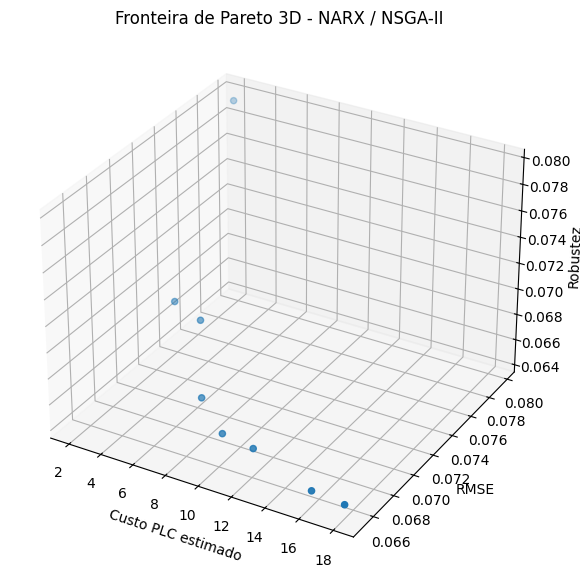

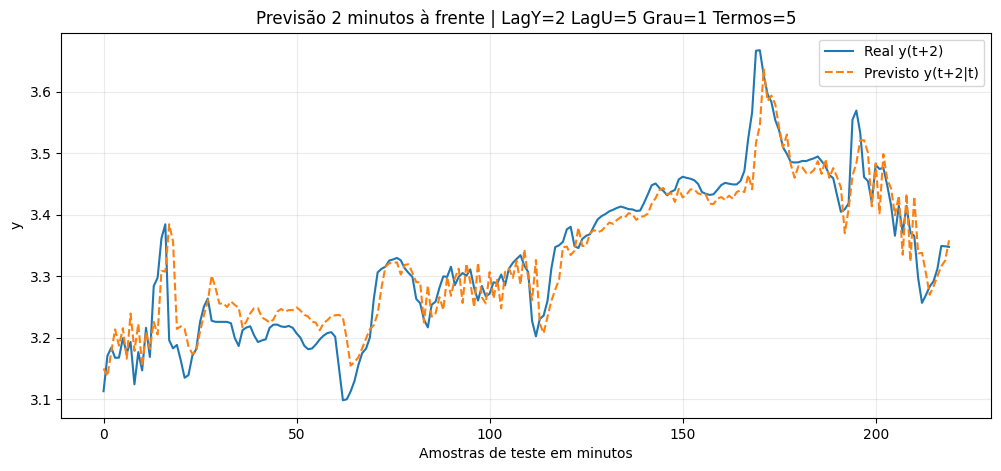

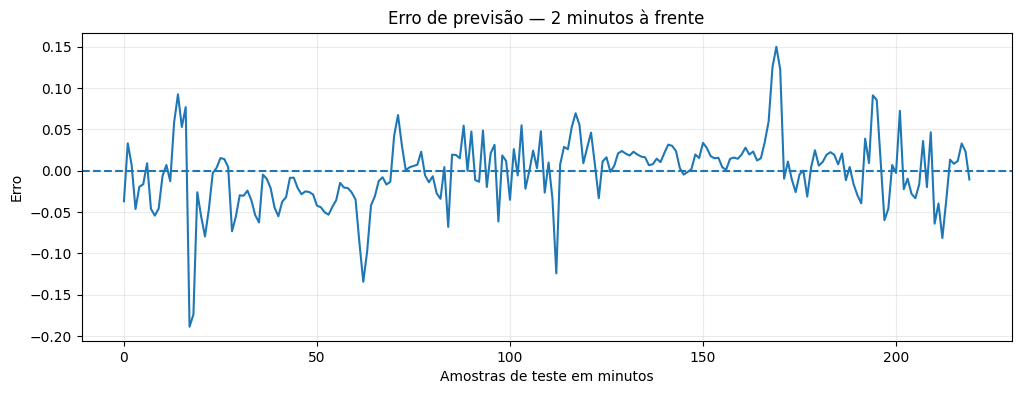

In [9]:
# ============================================================
# 8. Gráficos
# ============================================================

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_pareto["Custo_PLC"],
    df_pareto["RMSE"],
    df_pareto["Robustez_std_erro"]
)

ax.set_xlabel("Custo PLC estimado")
ax.set_ylabel("RMSE")
ax.set_zlabel("Robustez")
ax.set_title("Fronteira de Pareto 3D - NARX / NSGA-II")

plt.show()

n_plot = min(220, len(chosen.y_test))
erro = chosen.y_test - chosen.y_pred_test

plt.figure(figsize=(12, 5))
plt.plot(chosen.y_test[:n_plot], label=f"Real {col_y}(t+{H})")
plt.plot(chosen.y_pred_test[:n_plot], "--", label=f"Previsto {col_y}(t+{H}|t)")
plt.title(
    f"Previsão 2 minutos à frente | "
    f"LagY={chosen.lag_y} LagU={chosen.lag_u} "
    f"Grau={chosen.grau} Termos={chosen.n_terms}"
)
plt.xlabel("Amostras de teste em minutos")
plt.ylabel(col_y)
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(erro[:n_plot])
plt.axhline(0, linestyle="--")
plt.title("Erro de previsão — 2 minutos à frente")
plt.xlabel("Amostras de teste em minutos")
plt.ylabel("Erro")
plt.grid(True, alpha=0.25)
plt.show()


Faça upload do arquivo Excel (.xlsx)


Saving Temperatura.xlsx to Temperatura (1).xlsx
Dataset original em segundos: (43201, 6)
Colunas: ['TEMP', 'VAZÃO', 'POTÊNCIA', 'VALVULA', 'TEMP_1', 'TEMP_2']
Dataset convertido para minutos: (721, 6)
Geração 1/20 | RMSE min=9.9401 | Custo min=2 | Robustez min=9.4168
Geração 2/20 | RMSE min=8.6788 | Custo min=2 | Robustez min=8.3131
Geração 3/20 | RMSE min=8.5878 | Custo min=2 | Robustez min=8.0457
Geração 4/20 | RMSE min=8.1685 | Custo min=2 | Robustez min=7.8397
Geração 5/20 | RMSE min=8.0321 | Custo min=2 | Robustez min=7.7709
Geração 6/20 | RMSE min=7.7288 | Custo min=2 | Robustez min=7.6946
Geração 7/20 | RMSE min=7.7288 | Custo min=2 | Robustez min=7.6946
Geração 8/20 | RMSE min=7.3586 | Custo min=2 | Robustez min=7.3570
Geração 9/20 | RMSE min=7.3465 | Custo min=2 | Robustez min=7.3189
Geração 10/20 | RMSE min=7.3465 | Custo min=2 | Robustez min=7.3189
Geração 11/20 | RMSE min=7.3465 | Custo min=2 | Robustez min=7.3189
Geração 12/20 | RMSE min=7.3465 | Custo min=2 | Robustez min

,RMSE,MAE,R2,Custo_PLC,Robustez_std_erro,N_Termos,Lag_Y,Lag_U,Grau
0,7.113505,5.660733,0.970788,16,7.083251,8,5,5,1
1,7.304282,5.918310,0.969200,14,7.290478,7,5,5,1
2,7.352001,5.965530,0.968796,12,7.311846,6,5,5,1
3,7.457418,6.118796,0.967895,10,7.156496,5,4,2,1
4,7.493908,6.039621,0.967580,8,7.452744,4,4,2,2
5,7.817801,6.330387,0.964717,6,7.777223,3,4,2,1
6,7.817801,6.330387,0.964717,6,7.777223,3,4,3,1
7,8.494744,6.763777,0.958086,4,8.483022,2,2,2,1
8,9.954373,8.094115,0.942796,2,9.950771,1,2,5,1
9,9.954411,8.094278,0.942795,2,9.950742,1,2,4,2



Modelo escolhido por compromisso:
RMSE = 7.4939
MAE  = 6.0396
R²   = 0.9676
Custo PLC = 8
Termos = 4
LagY = 4
LagU = 2
Grau = 2


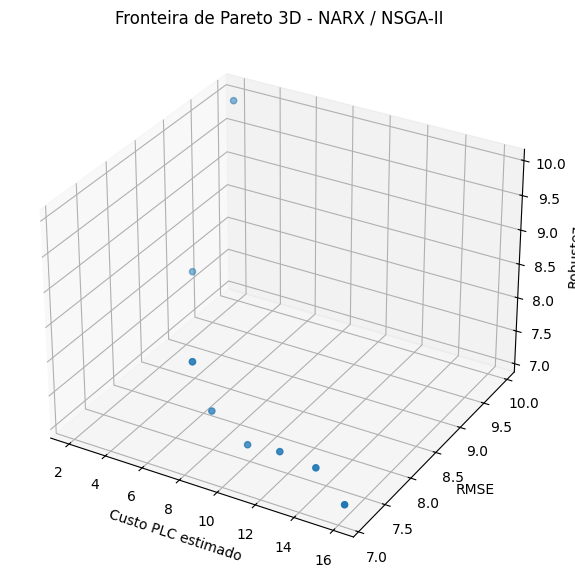

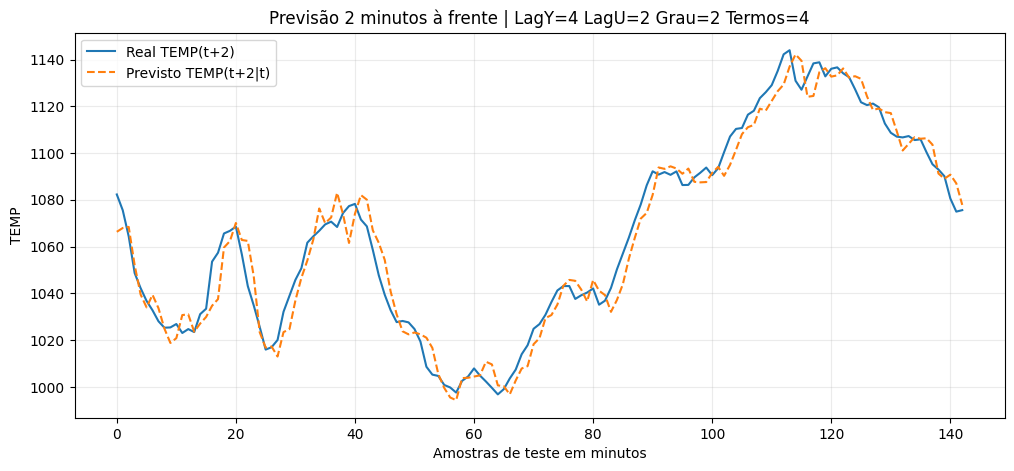

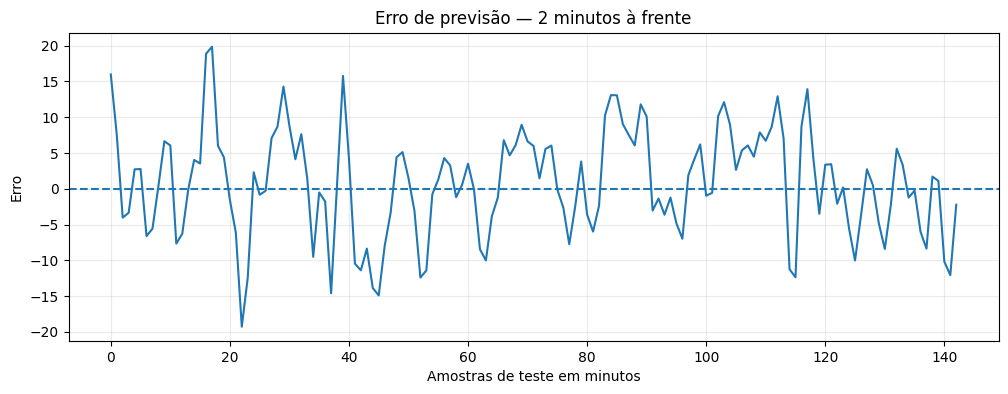

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# ============================================================
# 9. Exportação
# ============================================================

df_coef = pd.DataFrame({
    "Termo": chosen.names[chosen.mask],
    "Coeficiente": chosen.model.coef_
})

df_coef.loc[len(df_coef)] = ["Bias", chosen.model.intercept_]

df_info = pd.DataFrame([{
    "Amostragem": "media_60s",
    "Horizonte_minutos": H,
    "Horizonte_segundos": H * 60,
    "RMSE": chosen.rmse,
    "MAE": chosen.mae,
    "R2": chosen.r2,
    "Custo_PLC": chosen.cost,
    "Robustez_std_erro": chosen.robust,
    "N_Termos": chosen.n_terms,
    "Lag_Y": chosen.lag_y,
    "Lag_U": chosen.lag_u,
    "Grau": chosen.grau,
    "Amostras_minuto": len(df_min)
}])

df_pareto.to_excel("pareto_narx_nsga2_minutos.xlsx", index=False)
df_coef.to_excel("coeficientes_narx_nsga2_minutos.xlsx", index=False)
df_info.to_excel("resumo_narx_nsga2_minutos.xlsx", index=False)

files.download("pareto_narx_nsga2_minutos.xlsx")
files.download("coeficientes_narx_nsga2_minutos.xlsx")
files.download("resumo_narx_nsga2_minutos.xlsx")